<a href="https://colab.research.google.com/github/xPranavKrishna/BARC-Ion-Nanostructure-Prediction/blob/main/BARC_Nanostructure_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predictive modeling of ion-induced nanostructure formation on material surfaces based on incidence parameters

In [ ]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib



In [ ]:
# Load the dataset from Excel file

df = pd.read_excel('final_dataset.xlsx')
df.head()



,Ion,Target,Energy (eV),Angle (deg),Fluence (ions/cm²),Current (μA),Temperature (K),Structure obtained
0,Si,Si,35000,-,2000000000000000,-,300,Nanodot
1,Si,Si,50000,-,2000000000000000,-,300,Nanodot
2,Si,Si,75000,-,2000000000000000,-,300,Nanodot
3,Si,Si,100000,-,2000000000000000,-,300,Nanodot
4,Ar,Si,200,67,3000000000000000000,-,RT,Ripples


In [ ]:

print(df.isnull().sum())

Ion                   0
Target                0
Energy (eV)           0
Angle (deg)           0
Fluence (ions/cm²)    0
Current (μA)          0
Temperature (K)       0
Structure obtained    0
dtype: int64


In [ ]:
print(df.columns.tolist())


['Ion', 'Target', 'Energy (eV)', 'Angle (deg)', 'Fluence (ions/cm²)', 'Current (μA)', 'Temperature (K)', 'Structure obtained']


In [ ]:
# trimming and makeing lower all the column name
df.columns = df.columns.str.strip().str.lower()
df.columns.tolist()

['ion',
 'target',
 'energy (ev)',
 'angle (deg)',
 'fluence (ions/cm²)',
 'current (μa)',
 'temperature (k)',
 'structure obtained']

In [ ]:
# changing RT values to 298k in temperature
df['temperature (k)'] = df['temperature (k)'].replace('RT', 298)

In [ ]:
df.columns.tolist()

['ion',
 'target',
 'energy (ev)',
 'angle (deg)',
 'fluence (ions/cm²)',
 'current (μa)',
 'temperature (k)',
 'structure obtained']

In [ ]:
# adding nan values
df.replace("-", np.nan, inplace=True)
df.infer_objects(copy=False)
print(df.isnull().sum())

ion                     0
target                  0
energy (ev)             0
angle (deg)             4
fluence (ions/cm²)      1
current (μa)          110
temperature (k)        44
structure obtained      0
dtype: int64


/tmp/ipython-input-3995923026.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace("-", np.nan, inplace=True)


In [ ]:
# droping current(most values are empty)
df = df.drop(columns = ['current (μa)'])


In [ ]:
print(df.isnull().sum())

ion                    0
target                 0
energy (ev)            0
angle (deg)            4
fluence (ions/cm²)     1
temperature (k)       44
structure obtained     0
dtype: int64


In [ ]:
from sklearn.impute import SimpleImputer

In [ ]:
# df['energy (ev)'] = df['energy (ev)'].fillna(df['energy (ev)'].mean())
# df['angle (deg)'] = df['angle (deg)'].fillna(df['angle (deg)'].mean())
# df['fluence (ions/cm²)'] = df['fluence (ions/cm²)'].fillna(df['fluence (ions/cm²)'].mean())
# # df['current (μa)'] = df['current (μa)'].fillna(df['current (μa)'].mean())
# df['temperature (k)'] = df['temperature (k)'].fillna(df['temperature (k)'].mean())

# Step 1: Separate numeric and non-numeric columns
df['fluence (ions/cm²)'] = pd.to_numeric(df['fluence (ions/cm²)'], errors='coerce')

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
non_numeric_cols = df.select_dtypes(exclude=['float64', 'int64']).columns

# Step 2: Apply SimpleImputer only on numeric columns
simpleImp = SimpleImputer(strategy="mean")
df_numeric_imputed = pd.DataFrame(
    simpleImp.fit_transform(df[numeric_cols]),
    columns=numeric_cols
)

# Step 3: Combine with non-numeric part (unchanged or separately filled)
df_final = pd.concat([df_numeric_imputed, df[non_numeric_cols].reset_index(drop=True)], axis=1)

# Done!
df_final.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   energy (ev)         142 non-null    float64
 1   angle (deg)         142 non-null    float64
 2   fluence (ions/cm²)  142 non-null    float64
 3   temperature (k)     142 non-null    float64
 4   ion                 142 non-null    object 
 5   target              142 non-null    object 
 6   structure obtained  142 non-null    object 
dtypes: float64(4), object(3)
memory usage: 7.9+ KB


In [ ]:
print(df_final.isnull().sum())

energy (ev)           0
angle (deg)           0
fluence (ions/cm²)    0
temperature (k)       0
ion                   0
target                0
structure obtained    0
dtype: int64


In [ ]:
print(df_final['structure obtained'].value_counts())

structure obtained
Ripples                             29
Facets                              24
Triangular                          17
No Pattern                          11
Triangular Features with Ripples     7
Mounds                               5
Pyramidal Structures                 5
Ripple                               4
Nanodot                              4
Parallel-mode Ripples                4
Ripples parallel to beam             3
Terraced Ripples                     3
Faceted Mountain-like                3
Patterns                             3
Elongated Pyramids                   2
Roof-tile Patterns                   2
No Patterns                          2
Large Facets                         2
Nanorods                             1
Random                               1
Rare Patterns                        1
Disordered Ripples                   1
Large Ripples                        1
Some patterns                        1
Smooth                               1
Segmen

### Replacing same structure obtained

In [ ]:
structure_map = {
    # --- Ripples ---
    'ripples': 'ripples',
    'ripple': 'ripples',
    'parallel-mode ripples': 'ripples',
    'ripples parallel to beam': 'ripples',
    'terraced ripples': 'ripples',
    'segmented ripples': 'ripples',
    'disordered ripples': 'ripples',
    'rotated ripples': 'ripples',
    'large ripples': 'ripples',

    # --- Facets ---
    'facets': 'facets',
    'large facets': 'facets',
    'faceted mountain-like': 'facets',

    # --- Triangular ---
    'triangular': 'triangular',
    'triangular features with ripples': 'triangular',
    'no triangular features': 'no_triangular',

    # --- Pyramids ---
    'pyramidal structures': 'pyramids',
    'elongated pyramids': 'pyramids',
    'shadowed pyramids': 'pyramids',

    # --- Mounds & 3D Nano features ---
    'mounds': 'mounds',
    'nanodot': 'nano_features',
    'nanorods': 'nano_features',

    # --- Pattern or No Pattern ---
    'no pattern': 'no_pattern',
    'no patterns': 'no_pattern',
    'no pattern ': 'no_pattern',
    'patterns': 'patterned',
    'rare patterns': 'patterned',
    'some patterns': 'patterned',
    'roof-tile patterns': 'patterned',
    'random': 'patterned',

    # --- Smooth or Undefined ---
    'smooth': 'other',
}



In [ ]:
# Strip whitespace and convert to lowercase for consistent matching
df_final['structure obtained'] = df_final['structure obtained'].str.strip().str.lower()
# Replace variations with standardized labels using the structure_map
df_final['structure obtained'] = df_final['structure obtained'].replace(structure_map)

In [ ]:
print(df_final['structure obtained'].value_counts())

structure obtained
ripples          47
facets           29
triangular       24
no_pattern       14
pyramids          8
patterned         8
nano_features     5
mounds            5
other             1
no_triangular     1
Name: count, dtype: int64


In [ ]:
# Define structure labels with very few samples that may not be statistically significant
low_sample_classes = ['nanorods', 'smooth', 'no_triangular']
# Replace any label in the list with 'other' to reduce noise and class imbalance
df_final['structure obtained'] = df_final['structure obtained'].apply(
    lambda x: 'other' if x in low_sample_classes else x
)


In [ ]:
print(df_final['structure obtained'].value_counts())


structure obtained
ripples          47
facets           29
triangular       24
no_pattern       14
patterned         8
pyramids          8
nano_features     5
mounds            5
other             2
Name: count, dtype: int64


In [ ]:
print(df_final['ion'].value_counts())


ion
Ar     25
Kr     25
Xe     22
O2+    18
C+     17
Ar+    11
He     11
Cl      9
Si      4
Name: count, dtype: int64


In [ ]:
df_x = df_final.drop(columns = [ 'structure obtained'])
y = df_final['structure obtained']

In [ ]:
df_x.head()

,energy (ev),angle (deg),fluence (ions/cm²),temperature (k),ion,target
0,35000.0,60.753623,2.000000e+15,300.0,Si,Si
1,50000.0,60.753623,2.000000e+15,300.0,Si,Si
2,75000.0,60.753623,2.000000e+15,300.0,Si,Si
3,100000.0,60.753623,2.000000e+15,300.0,Si,Si
4,200.0,67.000000,3.000000e+18,298.0,Ar,Si


In [ ]:
df_x['target'].unique()


array(['Si', 'Si(100)'], dtype=object)

In [ ]:
# droping target feature- becouse it is always silicon
df_x = df_x.drop(columns = ['target'])


In [ ]:
print(df_x.columns.tolist())


['energy (ev)', 'angle (deg)', 'fluence (ions/cm²)', 'temperature (k)', 'ion']


### Encode data(label encoder and one-hot)

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

le = LabelEncoder()
ion_encoder = LabelEncoder()
# target encoding(stucture obtained)
target_encoder = LabelEncoder()



In [ ]:
# # encoing ion feature using one-hot enocode
# # df_encoded = pd.get_dummies(df_x, columns=['ion'])
# #encoding y -tareget  using label encoder
# df_encoded = df_x.copy()
# df_encoded['ion'] = ion_encoder.fit_transform(df_x['ion'])

# # Step 2: Save encoder (optional, but good practice)
# joblib.dump(ion_encoder, 'ion_encoder.pkl')

#  Create encoder with correct keyword
ion_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform 'ion' column
ion_encoded = ion_encoder.fit_transform(df_x[['ion']])
ion_encoded_df = pd.DataFrame(ion_encoded, columns=ion_encoder.get_feature_names_out(['ion']))

# Combine with rest of df_x (excluding 'ion')
df_encoded = pd.concat([df_x.drop(columns=['ion']).reset_index(drop=True), ion_encoded_df], axis=1)

# Save the encoder
joblib.dump(ion_encoder, 'ion_encoder.pkl')

# Now check the result
df_encoded.head()
y_encoded = target_encoder.fit_transform(y)


In [ ]:
df_encoded.head()

,energy (ev),angle (deg),fluence (ions/cm²),temperature (k),ion_Ar,ion_Ar+,ion_C+,ion_Cl,ion_He,ion_Kr,ion_O2+,ion_Si,ion_Xe
0,35000.0,60.753623,2.000000e+15,300.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,50000.0,60.753623,2.000000e+15,300.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,75000.0,60.753623,2.000000e+15,300.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,100000.0,60.753623,2.000000e+15,300.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,200.0,67.000000,3.000000e+18,298.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## EDA

In [ ]:
print(df_encoded.shape)


(142, 13)


In [ ]:
print(df_encoded.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   energy (ev)         142 non-null    float64
 1   angle (deg)         142 non-null    float64
 2   fluence (ions/cm²)  142 non-null    float64
 3   temperature (k)     142 non-null    float64
 4   ion_Ar              142 non-null    float64
 5   ion_Ar+             142 non-null    float64
 6   ion_C+              142 non-null    float64
 7   ion_Cl              142 non-null    float64
 8   ion_He              142 non-null    float64
 9   ion_Kr              142 non-null    float64
 10  ion_O2+             142 non-null    float64
 11  ion_Si              142 non-null    float64
 12  ion_Xe              142 non-null    float64
dtypes: float64(13)
memory usage: 14.6 KB
None


In [ ]:
print(df_encoded.describe())

         energy (ev)  angle (deg)  fluence (ions/cm²)  temperature (k)  \
count     142.000000   142.000000        1.420000e+02       142.000000   
mean    11008.063380    60.753623        2.683617e+20       358.064286   
std     34467.418703    22.278241        1.101572e+21       128.283558   
min        65.000000     0.000000        2.000000e+15       298.000000   
25%       300.000000    60.000000        4.200000e+17       298.000000   
50%       800.000000    67.000000        1.500000e+18       300.000000   
75%     10000.000000    70.000000        4.500000e+18       358.064286   
max    200000.000000    85.000000        5.000000e+21       850.000000   

           ion_Ar     ion_Ar+      ion_C+      ion_Cl      ion_He      ion_Kr  \
count  142.000000  142.000000  142.000000  142.000000  142.000000  142.000000   
mean     0.176056    0.077465    0.119718    0.063380    0.077465    0.176056   
std      0.382216    0.268274    0.325781    0.244508    0.268274    0.382216   
min      

In [ ]:
print(y.value_counts())

structure obtained
ripples          47
facets           29
triangular       24
no_pattern       14
patterned         8
pyramids          8
nano_features     5
mounds            5
other             2
Name: count, dtype: int64


### Plot distribution for numerical columns

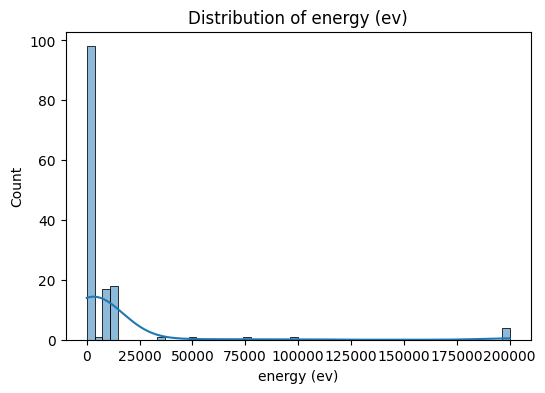

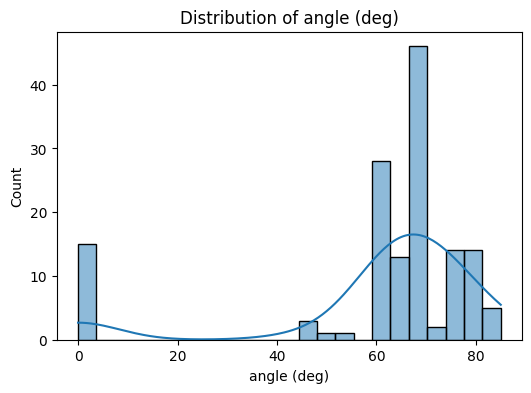

In [ ]:
num_cols = ['energy (ev)', 'angle (deg)', 'fluence (ions/cm²)', 'temperature (k)']

for col in num_cols[:2]:
    plt.figure(figsize=(6, 4))
    sns.histplot(df_encoded[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

<Axes: xlabel='fluence (ions/cm²)', ylabel='Count'>

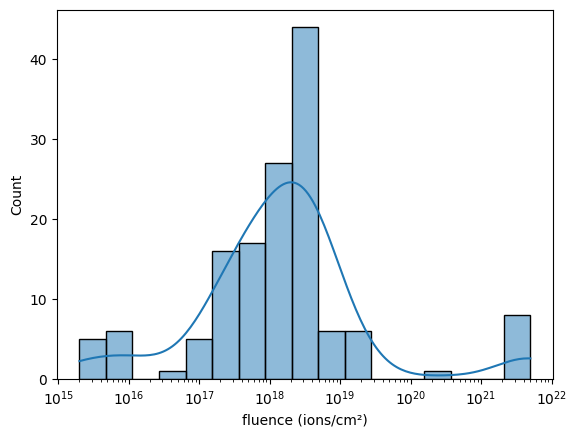

In [ ]:
sns.histplot(df_encoded['fluence (ions/cm²)'], kde=True, log_scale=True)


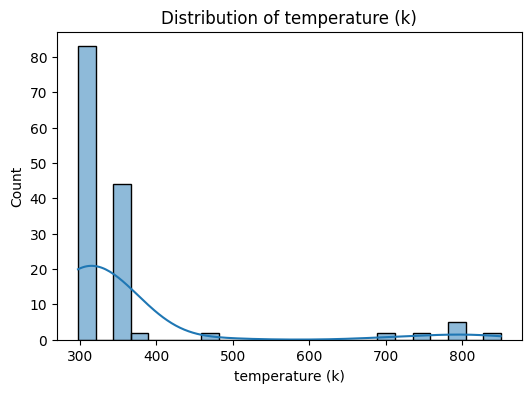

In [ ]:
for col in num_cols[3:]:
    plt.figure(figsize=(6, 4))
    sns.histplot(df_encoded[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

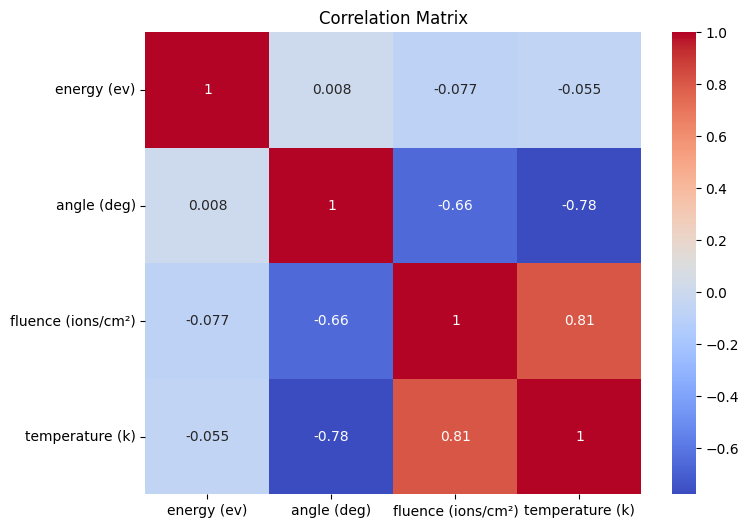

In [ ]:
corr = df_encoded[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.savefig('corr_without_ion.png', dpi=300)
plt.show()


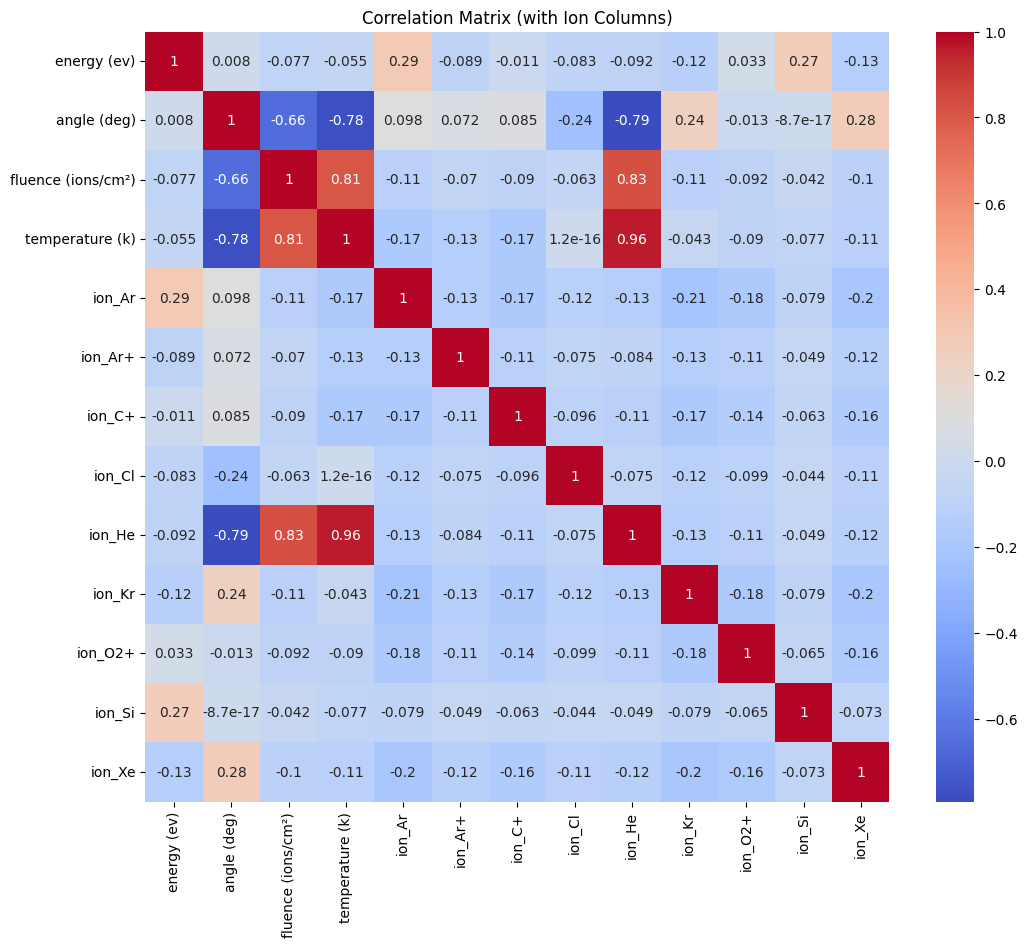

In [ ]:


ion_cols = [col for col in df_encoded.columns if col.startswith('ion_')]
corr = df_encoded[num_cols + ion_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix (with Ion Columns)")
plt.savefig('corr_with_ion.png', dpi=300)

plt.show()


In [ ]:
# ion_cols = [col for col in df_encoded.columns if col.startswith('ion_')]

# ion_counts = df_encoded[ion_cols].sum().sort_values(ascending=False)
# ion_counts.plot(kind='bar', title='Ion Type Frequency', figsize=(8, 4))
# plt.ylabel("Count")
# plt.show()

In [ ]:
df_full = df_encoded.copy()
df_full['structure obtained'] = y.values


In [ ]:
# Get all one-hot encoded ion columns
ion_cols = [col for col in df_encoded.columns if col.startswith('ion_')]

# Sum each column to get the count of 1s (i.e., how often that ion appears)
ion_distribution = df_encoded[ion_cols].sum().sort_values(ascending=False)

print(ion_distribution)


ion_Ar     25.0
ion_Kr     25.0
ion_Xe     22.0
ion_O2+    18.0
ion_C+     17.0
ion_Ar+    11.0
ion_He     11.0
ion_Cl      9.0
ion_Si      4.0
dtype: float64


In [ ]:
df_full.head(10)

,energy (ev),angle (deg),fluence (ions/cm²),temperature (k),ion_Ar,ion_Ar+,ion_C+,ion_Cl,ion_He,ion_Kr,ion_O2+,ion_Si,ion_Xe,structure obtained
0,35000.0,60.753623,2.000000e+15,300.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,nano_features
1,50000.0,60.753623,2.000000e+15,300.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,nano_features
2,75000.0,60.753623,2.000000e+15,300.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,nano_features
3,100000.0,60.753623,2.000000e+15,300.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,nano_features
4,200.0,67.000000,3.000000e+18,298.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ripples
5,300.0,67.000000,3.000000e+18,298.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,triangular
6,400.0,67.000000,3.000000e+18,298.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,triangular
7,500.0,67.000000,3.000000e+18,298.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,triangular
8,300.0,67.000000,5.000000e+17,298.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,patterned
9,300.0,67.000000,2.000000e+18,298.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,triangular


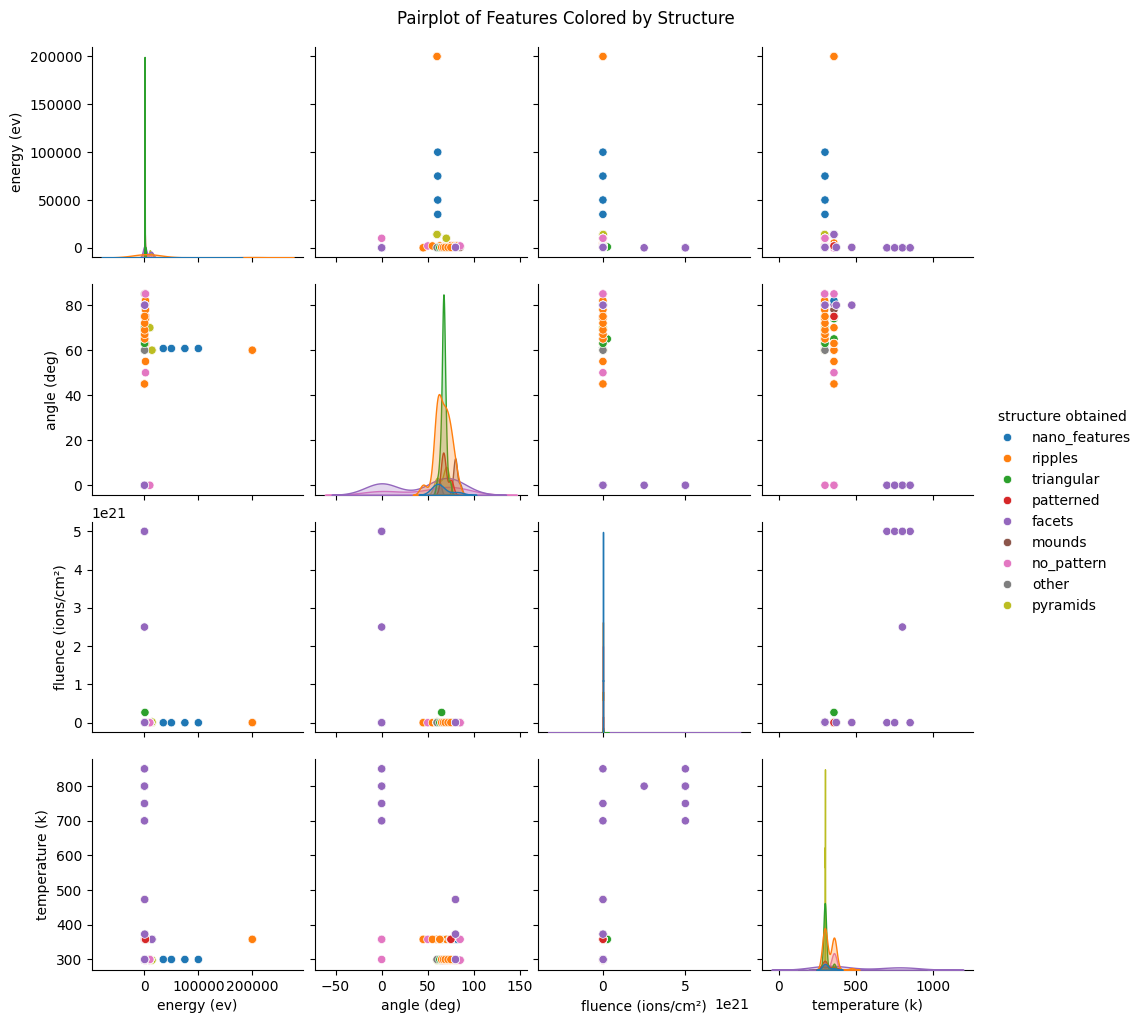

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Choose relevant numeric columns
num_cols = ['energy (ev)', 'angle (deg)', 'fluence (ions/cm²)',  'temperature (k)']

# Plot pairplot with class coloring (hue)
sns.pairplot(df_full, vars=num_cols, hue='structure obtained')
plt.suptitle("Pairplot of Features Colored by Structure", y=1.02)
plt.savefig('ml_pairplot_1.png',dpi=300)
plt.show()

###

```
# This is formatted as code
```

Countplot — See which ion leads to which structure

In [ ]:
df_full_copy = df_full.copy()
# Get ion column back from one-hot
df_full_copy['ion'] = df_full[['ion_Ar', 'ion_Ar+', 'ion_C+', 'ion_Cl', 'ion_He', 'ion_Kr', 'ion_O2+', 'ion_Si', 'ion_Xe']].idxmax(axis=1)



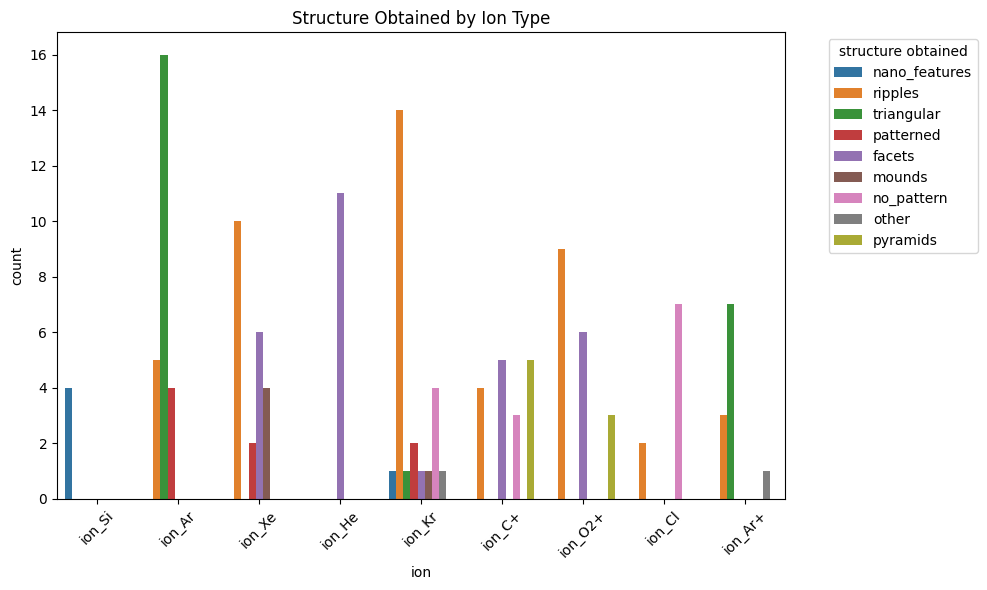

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='ion', hue='structure obtained', data=df_full_copy)
plt.title("Structure Obtained by Ion Type")
plt.xticks(rotation=45)

# Move legend outside the plot (right side)
plt.legend(title='structure obtained', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()  # Adjust layout to fit everything
plt.savefig('countplot_ion_structure.png',dpi=300)
plt.show()


### Log Trasnformation -Fluence , energy

Since the energy (ev) and fluence (ions/cm²) values were highly right-skewed, we applied a log transformation to normalize the distribution. All further analysis was done using the log-transformed value

In [ ]:
df_full_log = df_full.copy()
df_full_log['fluence (ions/cm²)'] = np.log10(df_full['fluence (ions/cm²)'] + 1)
df_full_log['energy (ev)'] = np.log10(df_full['energy (ev)'] + 1)


# import seaborn as sns
# sns.histplot(df['fluence (ions/cm²)'], kde=True)
# sns.histplot(np.log10(df['fluence (ions/cm²)'] + 1), kde=True)

df_full_log.columns

Index(['energy (ev)', 'angle (deg)', 'fluence (ions/cm²)', 'temperature (k)',
       'ion_Ar', 'ion_Ar+', 'ion_C+', 'ion_Cl', 'ion_He', 'ion_Kr', 'ion_O2+',
       'ion_Si', 'ion_Xe', 'structure obtained'],
      dtype='object')

<Axes: xlabel='fluence (ions/cm²)', ylabel='Count'>

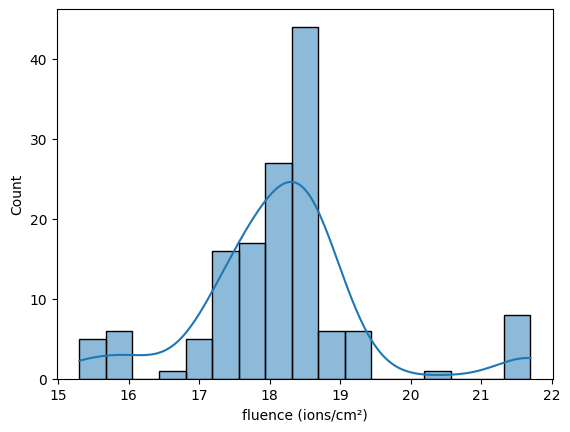

In [ ]:
sns.histplot(df_full_log['fluence (ions/cm²)'], kde=True)


<Axes: xlabel='energy (ev)', ylabel='Count'>

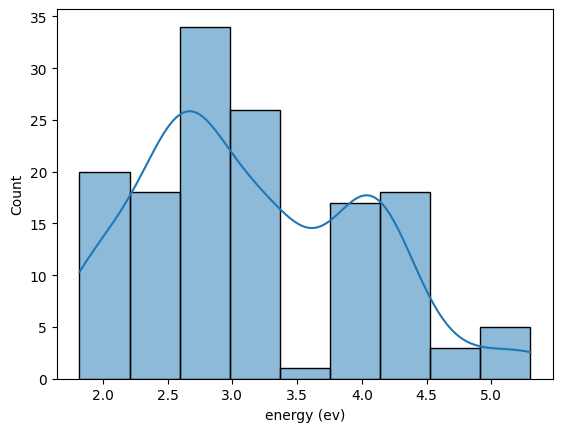

In [ ]:
# import matplotlib.pyplot as plt

# plt.hist(df['energy (ev)'], bins=50)
# plt.title('Energy (eV) Distribution')
# plt.xlabel('energy (ev)')
# plt.ylabel('Frequency')
# plt.grid(True)
# plt.show()
sns.histplot(df_full_log['energy (ev)'], kde=True)

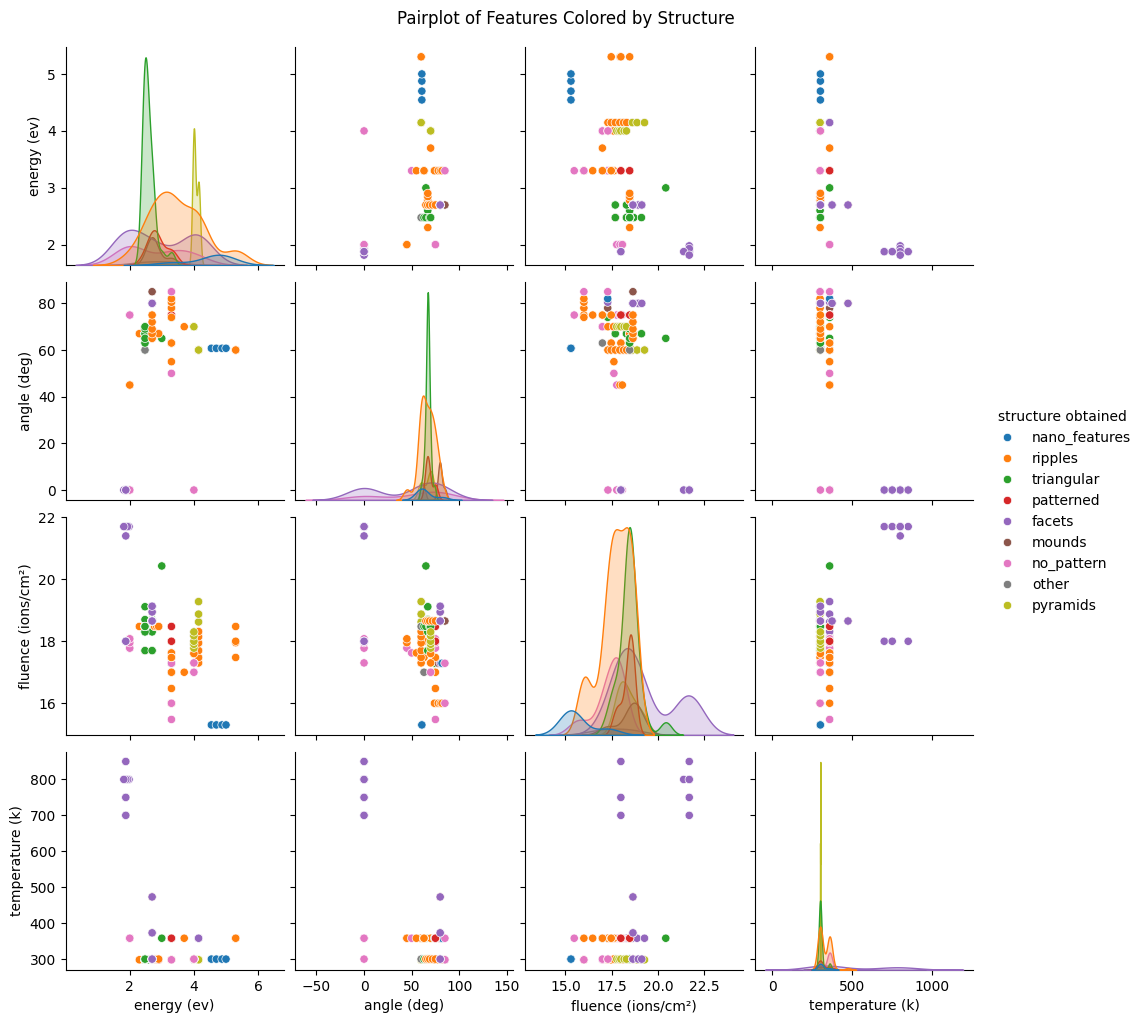

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Choose relevant numeric columns
num_cols = ['energy (ev)', 'angle (deg)', 'fluence (ions/cm²)',  'temperature (k)']

# Plot pairplot with class coloring (hue)
sns.pairplot(df_full_log, vars=num_cols, hue='structure obtained')
plt.suptitle("Pairplot of Features Colored by Structure", y=1.02)
plt.savefig('pairplot_after_log.png')
plt.show()

## Scaling the data

In [ ]:
from sklearn.preprocessing import StandardScaler


In [ ]:
# Separate the target column
structure_col = df_full_log['structure obtained']

#  Identify which columns to scale
columns_to_scale = ['energy (ev)', 'angle (deg)', 'fluence (ions/cm²)', 'temperature (k)']

#  Identify which columns NOT to scale (one-hot encoded ions)
columns_not_to_scale = [col for col in df_full_log.columns if col.startswith("ion_")]
# Apply StandardScaler only to selected numeric columns
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(df_full_log[columns_to_scale])

#  Create a DataFrame from the scaled data
df_scaled_numeric = pd.DataFrame(X_scaled_array, columns=columns_to_scale, index=df_full_log.index)

#  Concatenate the scaled numeric columns, unscaled one-hot columns, and target column
df_scaled = pd.concat([
    df_scaled_numeric,
    df_full_log[columns_not_to_scale],
    structure_col
], axis=1)




In [ ]:
df_scaled.head()

,energy (ev),angle (deg),fluence (ions/cm²),temperature (k),ion_Ar,ion_Ar+,ion_C+,ion_Cl,ion_He,ion_Kr,ion_O2+,ion_Si,ion_Xe,structure obtained
0,1.620634,-3.200692e-16,-2.348336,-0.454227,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,nano_features
1,1.801345,-3.200692e-16,-2.348336,-0.454227,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,nano_features
2,2.006776,-3.200692e-16,-2.348336,-0.454227,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,nano_features
3,2.152533,-3.200692e-16,-2.348336,-0.454227,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,nano_features
4,-0.993667,2.813727e-01,0.257618,-0.469872,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ripples


In [ ]:
df_scaled.describe()

,energy (ev),angle (deg),fluence (ions/cm²),temperature (k),ion_Ar,ion_Ar+,ion_C+,ion_Cl,ion_He,ion_Kr,ion_O2+,ion_Si,ion_Xe
count,1.420000e+02,1.420000e+02,1.420000e+02,1.420000e+02,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000
mean,-7.192994e-17,-2.908472e-16,3.052331e-15,3.002293e-16,0.176056,0.077465,0.119718,0.063380,0.077465,0.176056,0.126761,0.028169,0.154930
std,1.003540e+00,1.003540e+00,1.003540e+00,1.003540e+00,0.382216,0.268274,0.325781,0.244508,0.268274,0.382216,0.333882,0.166041,0.363118
min,-1.557915e+00,-2.736692e+00,-2.348336e+00,-4.698724e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-7.890735e-01,-3.394751e-02,-4.429763e-01,-4.698724e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-2.931751e-01,2.813727e-01,1.062552e-02,-4.542268e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.859400e-01,4.165099e-01,4.020992e-01,4.446761e-16,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2.503723e+00,1.092196e+00,2.901115e+00,3.848327e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### TSNE

In [ ]:
from sklearn.manifold import TSNE
le = LabelEncoder

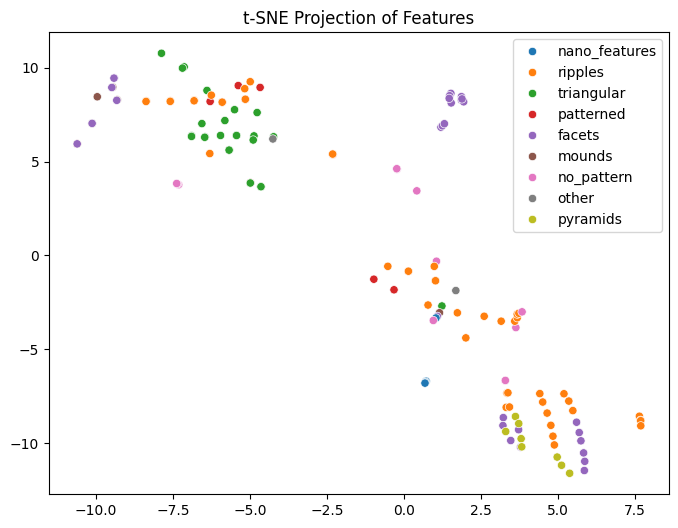

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df_scaled contains only numerical features and is standardized
# Ensure y_encoded is your target variable already label-encoded
# Ensure target_encoder is already fitted on the original labels

tsne = TSNE(random_state=42)
# tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, n_iter=1000, random_state=42)

X_tsne = tsne.fit_transform(df_scaled[num_cols])  # df_scaled must be standardized input

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1],
                hue=target_encoder.inverse_transform(y_encoded),
                palette='tab10')

plt.title("t-SNE Projection of Features")
plt.savefig("tsne.png", bbox_inches='tight')
plt.show()


### encoing stucture obtained

In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df_scaled['structure obtained'])
# saving the label encoder for target
joblib.dump(label_encoder, 'target_encoder.pkl')

['target_encoder.pkl']

## Split And Train Data

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:

# Separate features (X) and target (y)
X = df_scaled.drop('structure obtained', axis=1)
y = y_encoded  # already label encoded

# Split the dataset into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Data Balancing

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from collections import Counter

In [ ]:
print(Counter(y_train))

Counter({np.int64(7): 36, np.int64(0): 17, np.int64(8): 15, np.int64(3): 12, np.int64(6): 6, np.int64(5): 4, np.int64(1): 4, np.int64(2): 4, np.int64(4): 1})


In [ ]:
#  y_train_str = target_encoder.inverse_transform(y_train)



In [ ]:

from sklearn.model_selection import train_test_split
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

In [ ]:




# Step 1: Separate features and target
X = df_scaled.drop('structure obtained', axis=1)
y = y_encoded  # Assuming this is already LabelEncoded

# Step 2: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Print original class distribution
print("Original class distribution in training set:")
print(Counter(y_train))

# Step 4: Define major classes (you can adjust this if needed)
# IMPORTANT: These must be encoded label values, not string names like 'ripples'
# So you must map the string labels to encoded values correctly:
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
major_classes = [label_mapping[c] for c in ['ripples', 'facets', 'triangular'] if c in label_mapping]

# Step 5: Define oversampling strategy
over_strategy = {}
for cls in np.unique(y_train):
    count = sum(y_train == cls)

    if count < 2:
        print(f"Skipping oversampling for class {cls} (only {count} sample)")
        continue  # SMOTE requires at least 2 samples

    if cls in major_classes:
        over_strategy[cls] = max(15, count)  # Oversample to at least 15
    else:
        over_strategy[cls] = count  # No oversampling

# Step 6: Define undersampling strategy
under_strategy = {}
for cls in np.unique(y_train):
    count = sum(y_train == cls)

    if cls in major_classes:
        under_strategy[cls] = min(15, count)  # Undersample to at most 15
    else:
        under_strategy[cls] = min(10, count)  # Cap others at 10

print("\nOversampling strategy:", over_strategy)
print("Undersampling strategy:", under_strategy)

# Step 7: Create pipeline
smote = SMOTE(sampling_strategy=over_strategy, random_state=42, k_neighbors=1)
under = RandomUnderSampler(sampling_strategy=under_strategy, random_state=42)

pipeline = Pipeline([
    ('smote', smote),
    ('under', under)
])

# Step 8: Apply balancing
X_train_balanced, y_train_balanced = pipeline.fit_resample(X_train, y_train)

# Step 9: Show final balanced distribution
print("\nFinal class distribution after balancing:")
print(Counter(y_train_balanced))


Original class distribution in training set:
Counter({np.int64(7): 36, np.int64(0): 17, np.int64(8): 15, np.int64(3): 12, np.int64(6): 6, np.int64(5): 4, np.int64(1): 4, np.int64(2): 4, np.int64(4): 1})
Skipping oversampling for class 4 (only 1 sample)

Oversampling strategy: {np.int64(0): np.int64(17), np.int64(1): np.int64(4), np.int64(2): np.int64(4), np.int64(3): np.int64(12), np.int64(5): np.int64(4), np.int64(6): np.int64(6), np.int64(7): np.int64(36), np.int64(8): 15}
Undersampling strategy: {np.int64(0): 15, np.int64(1): np.int64(4), np.int64(2): np.int64(4), np.int64(3): 10, np.int64(4): np.int64(1), np.int64(5): np.int64(4), np.int64(6): np.int64(6), np.int64(7): 15, np.int64(8): 15}

Final class distribution after balancing:
Counter({np.int64(0): 15, np.int64(7): 15, np.int64(8): 15, np.int64(3): 10, np.int64(6): 6, np.int64(1): 4, np.int64(2): 4, np.int64(5): 4, np.int64(4): 1})


## Train Model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier


In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# def train_and_evaluate(model, name):
#     model.fit(X_train_balanced, y_train_balanced)
#     y_pred = model.predict(X_test)
#     print(f"\n{name} Results:")
#     print("Accuracy:", accuracy_score(y_test, y_pred))
#     print(classification_report(y_test, y_pred,zero_division=0))
# #
#
#
def train_and_evaluate(model, name):
    # Train the model on training data
    model.fit(X_train_balanced, y_train_balanced)
    # Predict on training data
    y_train_pred = model.predict(X_train_balanced)
    # Predict on test data
    y_test_pred = model.predict(X_test)
    print(f"\n{name} Results:")
    # Training Accuracy
    train_acc = accuracy_score(y_train_balanced, y_train_pred)
    print(f"Training Accuracy: {train_acc:.2f}")
    # Test Accuracy
    test_acc = accuracy_score(y_test, y_test_pred)
    print(f"Test Accuracy: {test_acc:.2f}")
    # Classification report
    print("\nClassification Report (on Test Data):")
    print(classification_report(y_test, y_test_pred, zero_division=0))

In [ ]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
train_and_evaluate(lr, "Logistic Regression")

# Random Forest
rf = RandomForestClassifier(random_state=42)
train_and_evaluate(rf, "Random Forest")

# Support Vector Machine
svc = SVC()
train_and_evaluate(svc, "Support Vector Classifier")

# XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
train_and_evaluate(xgb, "XGBoost")





Logistic Regression Results:
Training Accuracy: 0.69
Test Accuracy: 0.63

Classification Report (on Test Data):
              precision    recall  f1-score   support

           0       0.67      0.67      0.67        12
           1       0.00      0.00      0.00         1
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         2
           4       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         4
           6       0.00      0.00      0.00         2
           7       0.54      0.64      0.58        11
           8       0.64      1.00      0.78         9

    accuracy                           0.63        43
   macro avg       0.43      0.48      0.45        43
weighted avg       0.53      0.63      0.57        43


Random Forest Results:
Training Accuracy: 1.00
Test Accuracy: 0.77

Classification Report (on Test Data):
              precision    recall  f1-score   support

           0       0

/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [18:14:22] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Results:
Training Accuracy: 0.99
Test Accuracy: 0.67

Classification Report (on Test Data):
              precision    recall  f1-score   support

           0       0.75      0.75      0.75        12
           1       0.00      0.00      0.00         1
           2       1.00      1.00      1.00         1
           3       0.67      1.00      0.80         2
           4       0.00      0.00      0.00         1
           5       0.67      0.50      0.57         4
           6       0.00      0.00      0.00         2
           7       0.70      0.64      0.67        11
           8       0.67      0.89      0.76         9

    accuracy                           0.67        43
   macro avg       0.49      0.53      0.51        43
weighted avg       0.64      0.67      0.65        43



## Confusion Matrix

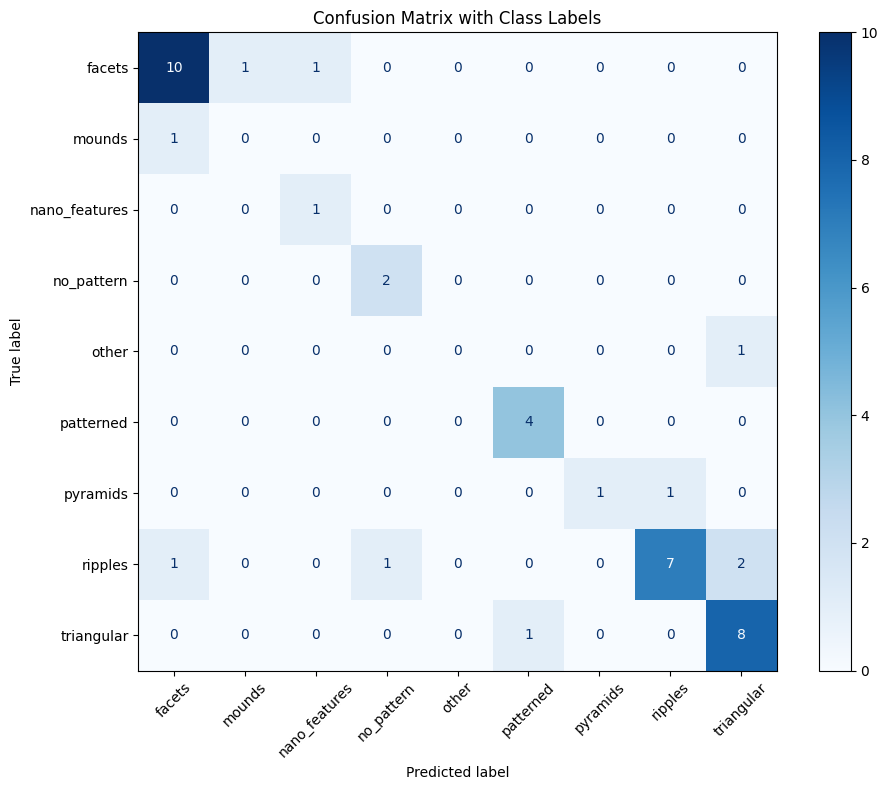

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Fit and predict
rf.fit(X_train_balanced, y_train_balanced)
y_pred = rf.predict(X_test)

# Ensure same label order as in y_test
labels = np.unique(y_test)
class_names = target_encoder.inverse_transform(labels)

# Create and plot confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))  # optional: larger size
disp.plot(cmap='Blues', xticks_rotation=45, ax=ax)

plt.title("Confusion Matrix with Class Labels")
plt.tight_layout()  # avoid cutoff of class names
plt.savefig('confusion1.png', dpi=300)
plt.show()


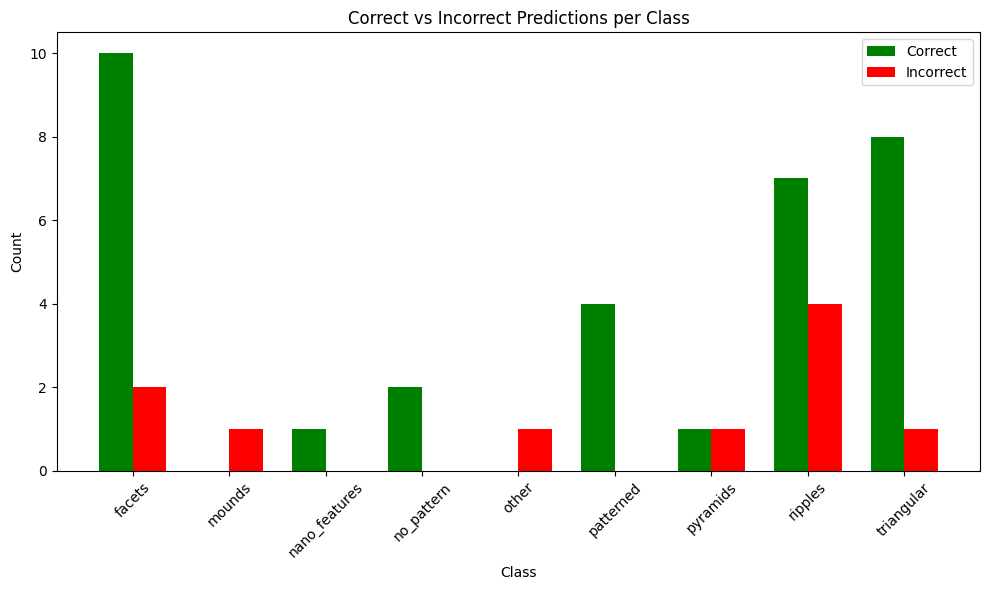

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute confusion matrix again (if needed)
cm = confusion_matrix(y_test, y_pred)
class_names = target_encoder.inverse_transform(sorted(np.unique(y_test)))

correct = np.diag(cm)
total = np.sum(cm, axis=1)
incorrect = total - correct

# Bar plot
x = np.arange(len(class_names))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, correct, width, label='Correct', color='green')
plt.bar(x + width/2, incorrect, width, label='Incorrect', color='red')
plt.xticks(x, class_names, rotation=45)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Correct vs Incorrect Predictions per Class")
plt.legend()
plt.tight_layout()
plt.savefig("correct_vs_incorrect.png")
plt.show()




```
# This is formatted as code
```

## Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV , cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

# === Step 1: Define the parameter grid ===
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced']  # Try both options
}

# === Step 2: Setup GridSearchCV ===
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='f1_weighted',  # Use weighted F1-score to handle class imbalance
    n_jobs=-1,  # Use all available CPU cores
    verbose=2   # Print progress (optional)
)

# === Step 3: Fit on balanced training data ===
grid_search.fit(X_train_balanced, y_train_balanced)

# === Step 4: Get the best model ===
best_rf = grid_search.best_estimator_

# === Step 5: Define evaluation function ===
def evaluate_model(model, X_test, y_test, model_name="Model"):
    print(f"\n✅ Evaluation for {model_name}")
    y_pred = model.predict(X_test)
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

# === Step 6: Evaluate on test data ===
evaluate_model(best_rf, X_test, y_test, "Tuned Random Forest")

# === Step 7: Print best parameters ===
print(f"\n🎯 Best parameters found: {grid_search.best_params_}")



Fitting 5 folds for each of 54 candidates, totalling 270 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(



✅ Evaluation for Tuned Random Forest
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        12
           1       0.00      0.00      0.00         1
           2       0.50      1.00      0.67         1
           3       0.67      1.00      0.80         2
           4       0.00      0.00      0.00         1
           5       1.00      1.00      1.00         4
           6       1.00      0.50      0.67         2
           7       0.88      0.64      0.74        11
           8       0.75      1.00      0.86         9

    accuracy                           0.79        43
   macro avg       0.62      0.66      0.62        43
weighted avg       0.80      0.79      0.78        43

Confusion Matrix:
[[10  1  1  0  0  0  0  0  0]
 [ 1  0  0  0  0  0  0  0  0]
 [ 0  0  1  0  0  0  0  0  0]
 [ 0  0  0  2  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  1]
 [ 0  0  0  0  0  4  0  0  0]
 [ 0  0  0  0  0  0  1  1  0]
 [ 1  

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print("✅ Best Parameters Found:", grid_search.best_params_)

✅ Best Parameters Found: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 300}


In [ ]:

# Train on balanced data
best_rf.fit(X_train_balanced, y_train_balanced)
# Predict on training data (for training accuracy)
y_train_pred = best_rf.predict(X_train_balanced)
# Predict on original test set
y_pred_rfc_tuned = best_rf.predict(X_test)

# Evaluate
print("✅ Tuned Random Forest Results:")
print("\nClassification Report (on Train Data):")
train_accuracy = accuracy_score(y_train_balanced, y_train_pred)
print(f"Training Accuracy: {train_accuracy:.2f}")

print("\nClassification Report (on Test Data):")
print("Accuracy:", accuracy_score(y_test, y_pred_rfc_tuned))
print(classification_report(y_test, y_pred_rfc_tuned, zero_division=0))

✅ Tuned Random Forest Results:

Classification Report (on Train Data):
Training Accuracy: 1.00

Classification Report (on Test Data):
Accuracy: 0.7906976744186046
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        12
           1       0.00      0.00      0.00         1
           2       0.50      1.00      0.67         1
           3       0.67      1.00      0.80         2
           4       0.00      0.00      0.00         1
           5       1.00      1.00      1.00         4
           6       1.00      0.50      0.67         2
           7       0.88      0.64      0.74        11
           8       0.75      1.00      0.86         9

    accuracy                           0.79        43
   macro avg       0.62      0.66      0.62        43
weighted avg       0.80      0.79      0.78        43



In [ ]:
print('rfc tuned :',classification_report(y_test,y_pred_rfc_tuned , zero_division=0))

rfc tuned :               precision    recall  f1-score   support

           0       0.83      0.83      0.83        12
           1       0.00      0.00      0.00         1
           2       0.50      1.00      0.67         1
           3       0.67      1.00      0.80         2
           4       0.00      0.00      0.00         1
           5       1.00      1.00      1.00         4
           6       1.00      0.50      0.67         2
           7       0.88      0.64      0.74        11
           8       0.75      1.00      0.86         9

    accuracy                           0.79        43
   macro avg       0.62      0.66      0.62        43
weighted avg       0.80      0.79      0.78        43



## RFC training and cross validation

## Confusion Matrix for Tuned model

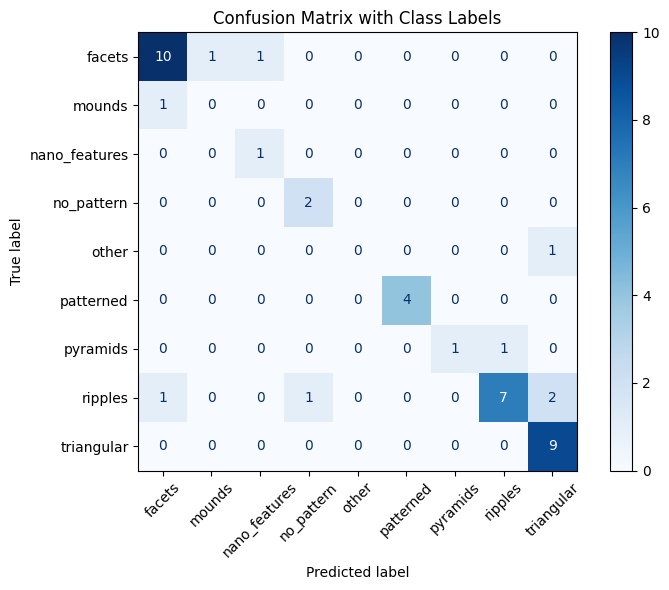

In [ ]:
# For tuned model:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Fit model and predict
best_rf.fit(X_train_balanced, y_train_balanced)
y_pred = best_rf.predict(X_test)

# Get class names from label encoder
unique_labels = np.unique(y_test)
class_names = target_encoder.inverse_transform(unique_labels)

# Create confusion matrix and plot
cm = confusion_matrix(y_test, y_pred, labels=unique_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 6))  # Optional: make it a bit larger
disp.plot(cmap='Blues', xticks_rotation=45, ax=ax)

plt.title("Confusion Matrix with Class Labels")
plt.tight_layout()  # Fix for label clipping
plt.savefig('confusion_tuned.png', dpi=300)
plt.show()

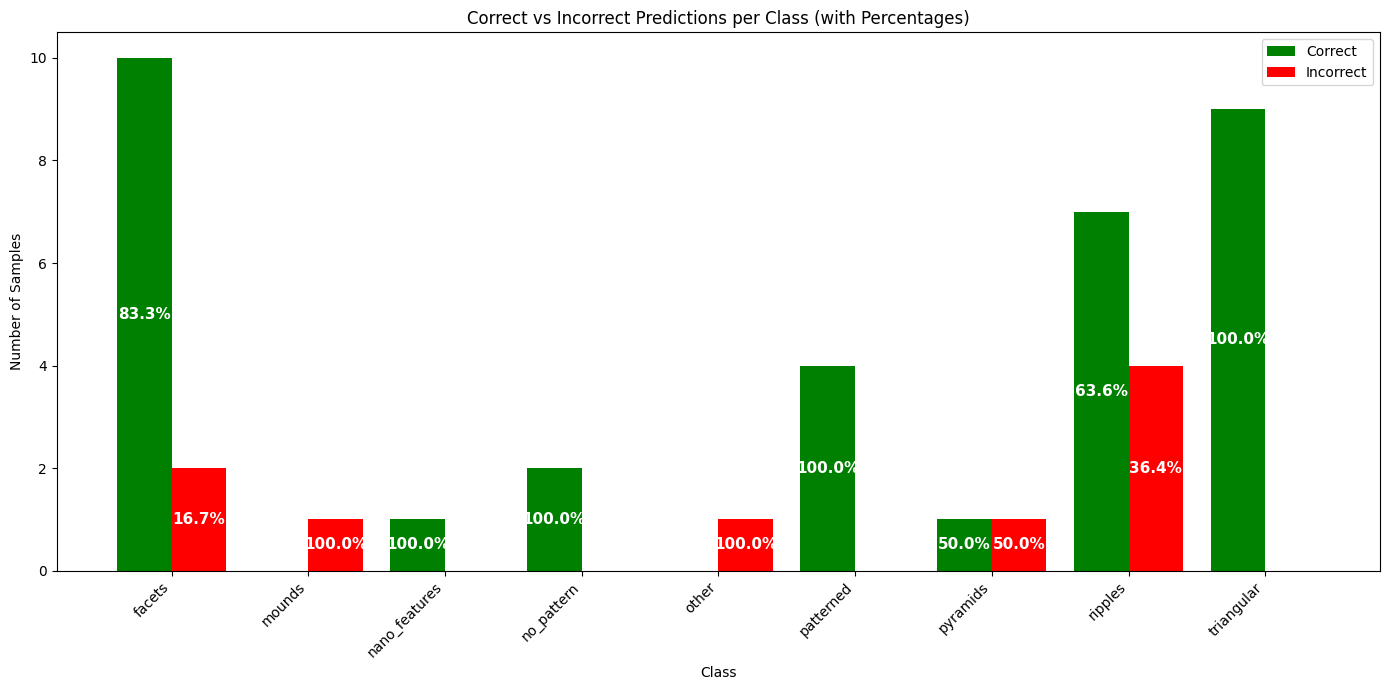

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Predict using the best model
y_pred = best_rf.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=np.unique(y_test))

# Class labels
class_names = target_encoder.inverse_transform(np.unique(y_test))

# Calculate values
correct = np.diag(cm)
total = np.sum(cm, axis=1)
incorrect = total - correct

# Percentages
correct_pct = (correct / total) * 100
incorrect_pct = (incorrect / total) * 100

# Plotting
x = np.arange(len(class_names))
width = 0.4  # Increased width

plt.figure(figsize=(14, 7))

bars_correct = plt.bar(x - width/2, correct, width, label='Correct', color='green')
bars_incorrect = plt.bar(x + width/2, incorrect, width, label='Incorrect', color='red')

# Annotations inside bars
for i in range(len(x)):
    if correct[i] > 0:
        plt.text(x[i] - width/2, correct[i]/2, f"{correct_pct[i]:.1f}%", ha='center', va='center', color='white', fontsize=11, fontweight='bold')
    if incorrect[i] > 0:
        plt.text(x[i] + width/2, incorrect[i]/2, f"{incorrect_pct[i]:.1f}%", ha='center', va='center', color='white', fontsize=11, fontweight='bold')

# Axes and labels
plt.xticks(x, class_names, rotation=45, ha='right')
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Correct vs Incorrect Predictions per Class (with Percentages)")
plt.legend()
plt.tight_layout()
plt.savefig("correct_vs_incorrect_widebars.png", dpi=300)
plt.show()


In [ ]:
print(pipeline.named_steps.keys())  # See the available keys



dict_keys(['smote', 'under'])




```
# This is formatted as code
```

## feature_importances

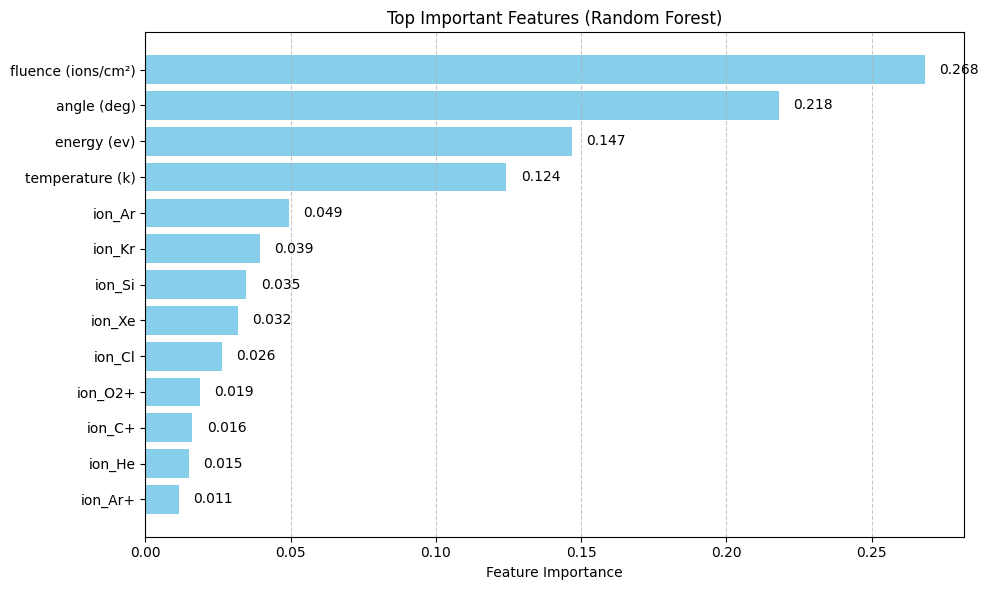

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Get feature importances
importances = best_rf.feature_importances_
feature_names = X_train_balanced.columns  # Or use X.columns if the order matches

# Create a DataFrame for sorting
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot top N features (e.g., top 15)
top_n = 15
top_features = feat_imp_df.head(top_n)

plt.figure(figsize=(10, 6))
bars = plt.barh(top_features['Feature'][::-1], top_features['Importance'][::-1], color='skyblue')
plt.xlabel("Feature Importance")
plt.title(f"Top Important Features (Random Forest)")
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add importance value on bars
for bar in bars:
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
             f"{bar.get_width():.3f}", va='center')

plt.tight_layout()
plt.savefig('feature_importance.png',dpi=300)
plt.show()


### testing

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:



# Define final pipeline with tuned model
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', best_rf)  # Insert your tuned Random Forest
])

# Fit the pipeline on full balanced training data
pipeline.fit(X_train_balanced, y_train_balanced)

# Evaluate on original (unbalanced) test set
evaluate_model(pipeline, X_test, y_test, "Final Pipeline with Tuned RF")


✅ Evaluation for Final Pipeline with Tuned RF
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        12
           1       0.00      0.00      0.00         1
           2       0.50      1.00      0.67         1
           3       0.67      1.00      0.80         2
           4       0.00      0.00      0.00         1
           5       1.00      1.00      1.00         4
           6       1.00      0.50      0.67         2
           7       0.88      0.64      0.74        11
           8       0.75      1.00      0.86         9

    accuracy                           0.79        43
   macro avg       0.62      0.66      0.62        43
weighted avg       0.80      0.79      0.78        43

Confusion Matrix:
[[10  1  1  0  0  0  0  0  0]
 [ 1  0  0  0  0  0  0  0  0]
 [ 0  0  1  0  0  0  0  0  0]
 [ 0  0  0  2  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  1]
 [ 0  0  0  0  0  4  0  0  0]
 [ 0  0  0  0  0  0  1  1  

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Save the model

In [ ]:
import joblib

# Save the full pipeline to a file
joblib.dump(pipeline, 'tuned_rf_pipeline.pkl')

print("✅ Model pipeline saved as 'tuned_rf_pipeline.pkl'")


✅ Model pipeline saved as 'tuned_rf_pipeline.pkl'


### Sample data

In [ ]:
# sample = pd.DataFrame([{
#     'energy (ev)': 200.0,
#     'angle (deg)': 100,
#     'fluence (ions/cm²)': 1.0e+18,
#     'temperature (k)': 500.0,
#     'ion_Ar': 0,
#     'ion_Ar+': 1,
#     'ion_C+': 0,
#     'ion_Cl': 0,
#     'ion_He': 0,
#     'ion_Kr': 0,
#     'ion_O2+': 0,
#     'ion_Si': 0,
#     'ion_Xe': 0
# }])
sample = pd.DataFrame([{
    'energy (ev)': 200.0,
    'angle (deg)': 100,
    'fluence (ions/cm²)': 1.0e+18,
    'temperature (k)': 500.0,
    'ion_Ar': 0,
    'ion_Ar+': 1,
    'ion_C+': 0,
    'ion_Cl': 0,
    'ion_He': 0,
    'ion_Kr': 0,
    'ion_O2+': 0,
    'ion_Si': 0,
    'ion_Xe': 0
}])


### Load the model later

In [ ]:
# # Load the saved pipeline
# loaded_pipeline = joblib.load('tuned_rf_pipeline.pkl')

# # Use it to predict
# prediction = loaded_pipeline.predict(sample)
# prediction_label = target_encoder.inverse_transform(prediction)
# print(" Predicted structure:", prediction_label[0])

# Load pipeline and encoder
loaded_pipeline = joblib.load('tuned_rf_pipeline.pkl')
target_encoder = joblib.load('target_encoder.pkl')

# Predict
prediction = loaded_pipeline.predict(sample)
prediction_label = target_encoder.inverse_transform(prediction)
print("Predicted structure:", prediction_label[0])


Predicted structure: facets


In [ ]:
# probs = loaded_pipeline.predict_proba(sample)
# for i, class_name in enumerate(target_encoder.classes_):
#     print(f"{class_name}: {probs[0][i]*100:.2f}%")


### DecisionTree

In [ ]:
from sklearn.tree import DecisionTreeClassifier


In [ ]:
# 1. Separate features and target
X = df_full_log.drop(columns=['structure obtained'])  # features only
y = df_full_log['structure obtained']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [ ]:
dtree = DecisionTreeClassifier(max_depth=6, min_samples_leaf=4, random_state=42)
dtree.fit(X, y_encoded)


DecisionTreeClassifier(max_depth=6, min_samples_leaf=4, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predict on training data
y_pred = dtree.predict(X)

# Accuracy
accuracy = accuracy_score(y_encoded, y_pred)
print(f"\n✅ Training Accuracy: {accuracy * 100:.2f}%")

# Optional: Confusion Matrix and Classification Report
print("\nConfusion Matrix:")
print(confusion_matrix(y_encoded, y_pred))

print("\nClassification Report:")
print(classification_report(y_encoded, y_pred, target_names=label_encoder.classes_))



✅ Training Accuracy: 67.61%

Confusion Matrix:
[[23  0  0  0  0  0  5  1  0]
 [ 4  0  0  0  0  0  0  1  0]
 [ 0  0  4  0  0  0  0  1  0]
 [ 0  0  0  7  0  0  0  6  1]
 [ 0  0  0  0  0  0  0  1  1]
 [ 0  0  0  0  0  0  0  7  1]
 [ 0  0  0  0  0  0  8  0  0]
 [ 4  0  0  3  0  0  3 36  1]
 [ 0  0  0  0  0  0  0  6 18]]

Classification Report:
               precision    recall  f1-score   support

       facets       0.74      0.79      0.77        29
       mounds       0.00      0.00      0.00         5
nano_features       1.00      0.80      0.89         5
   no_pattern       0.70      0.50      0.58        14
        other       0.00      0.00      0.00         2
    patterned       0.00      0.00      0.00         8
     pyramids       0.50      1.00      0.67         8
      ripples       0.61      0.77      0.68        47
   triangular       0.82      0.75      0.78        24

     accuracy                           0.68       142
    macro avg       0.49      0.51      0.49      

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from collections import Counter
print(Counter(y_encoded))


Counter({np.int64(7): 47, np.int64(0): 29, np.int64(8): 24, np.int64(3): 14, np.int64(5): 8, np.int64(6): 8, np.int64(2): 5, np.int64(1): 5, np.int64(4): 2})


In [ ]:
from sklearn.tree import plot_tree

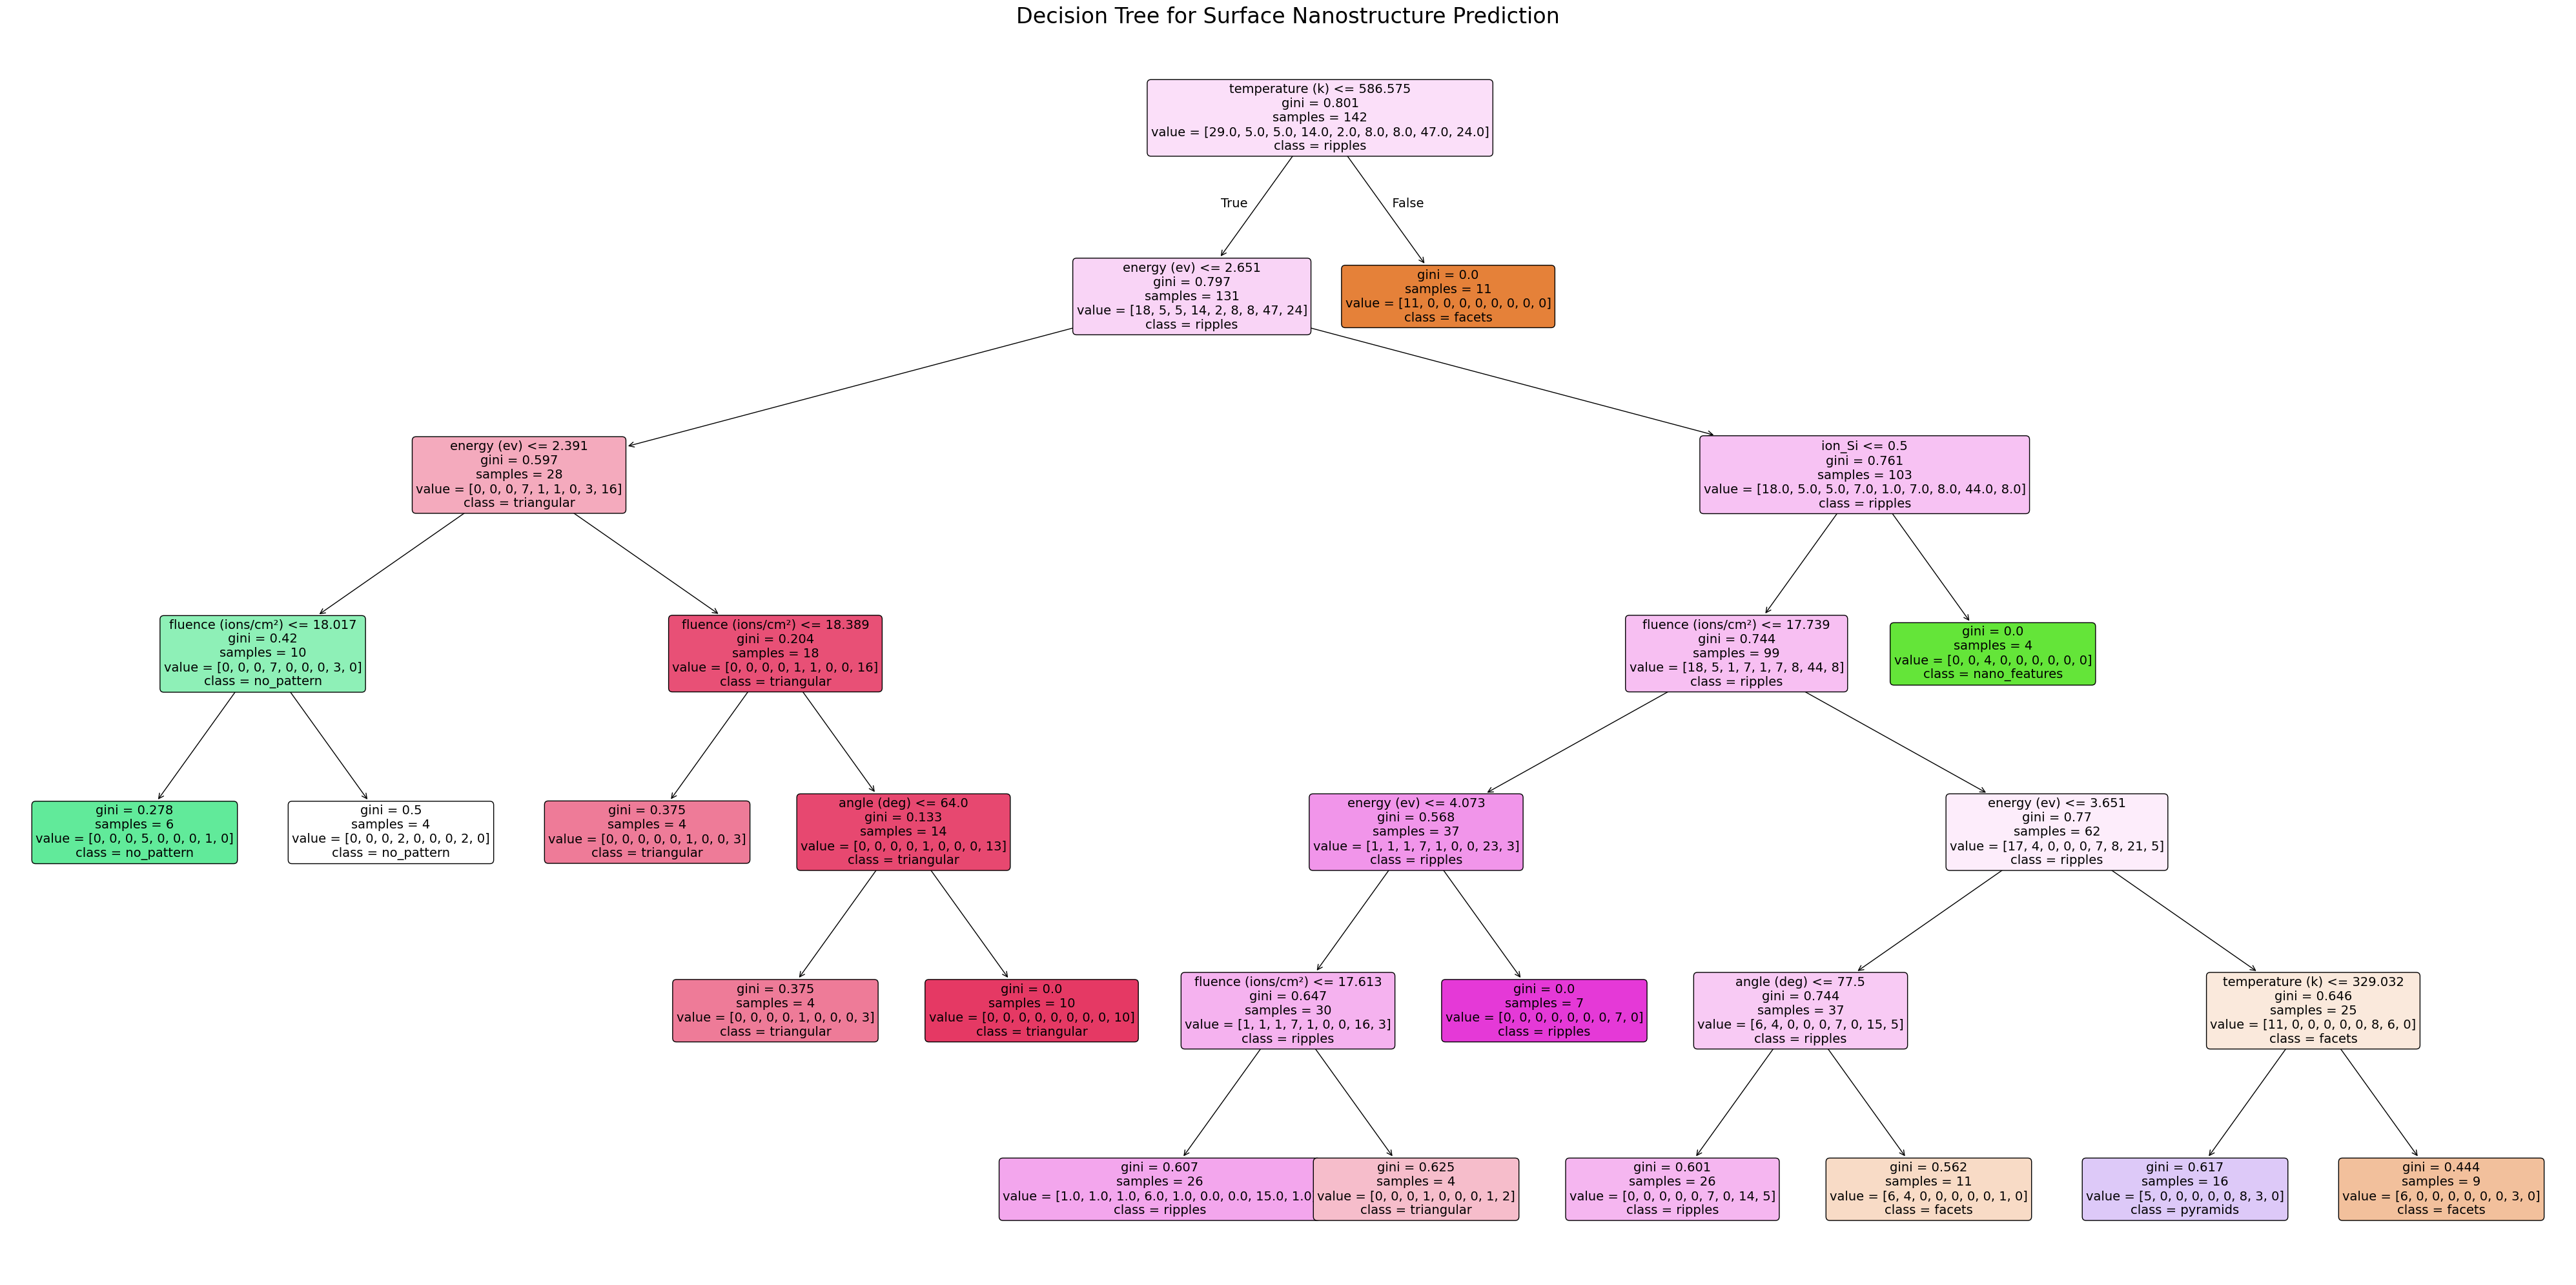

In [ ]:
plt.figure(figsize=(40, 20))
plot_tree(dtree,
          feature_names=X.columns,
          class_names=label_encoder.classes_,
          filled=True,
          rounded=True,
          fontsize=14)
plt.title("Decision Tree for Surface Nanostructure Prediction", fontsize=24)
plt.tight_layout()
plt.savefig("Dtree_new.png", dpi=300)
plt.show()



In [ ]:
# Export as pdf
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    dtree,
    out_file=None,
    feature_names=df_encoded.columns,
    class_names=label_encoder.classes_,
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph.render("nanostructure_decision_tree", format='pdf', cleanup=True)


'nanostructure_decision_tree.pdf'

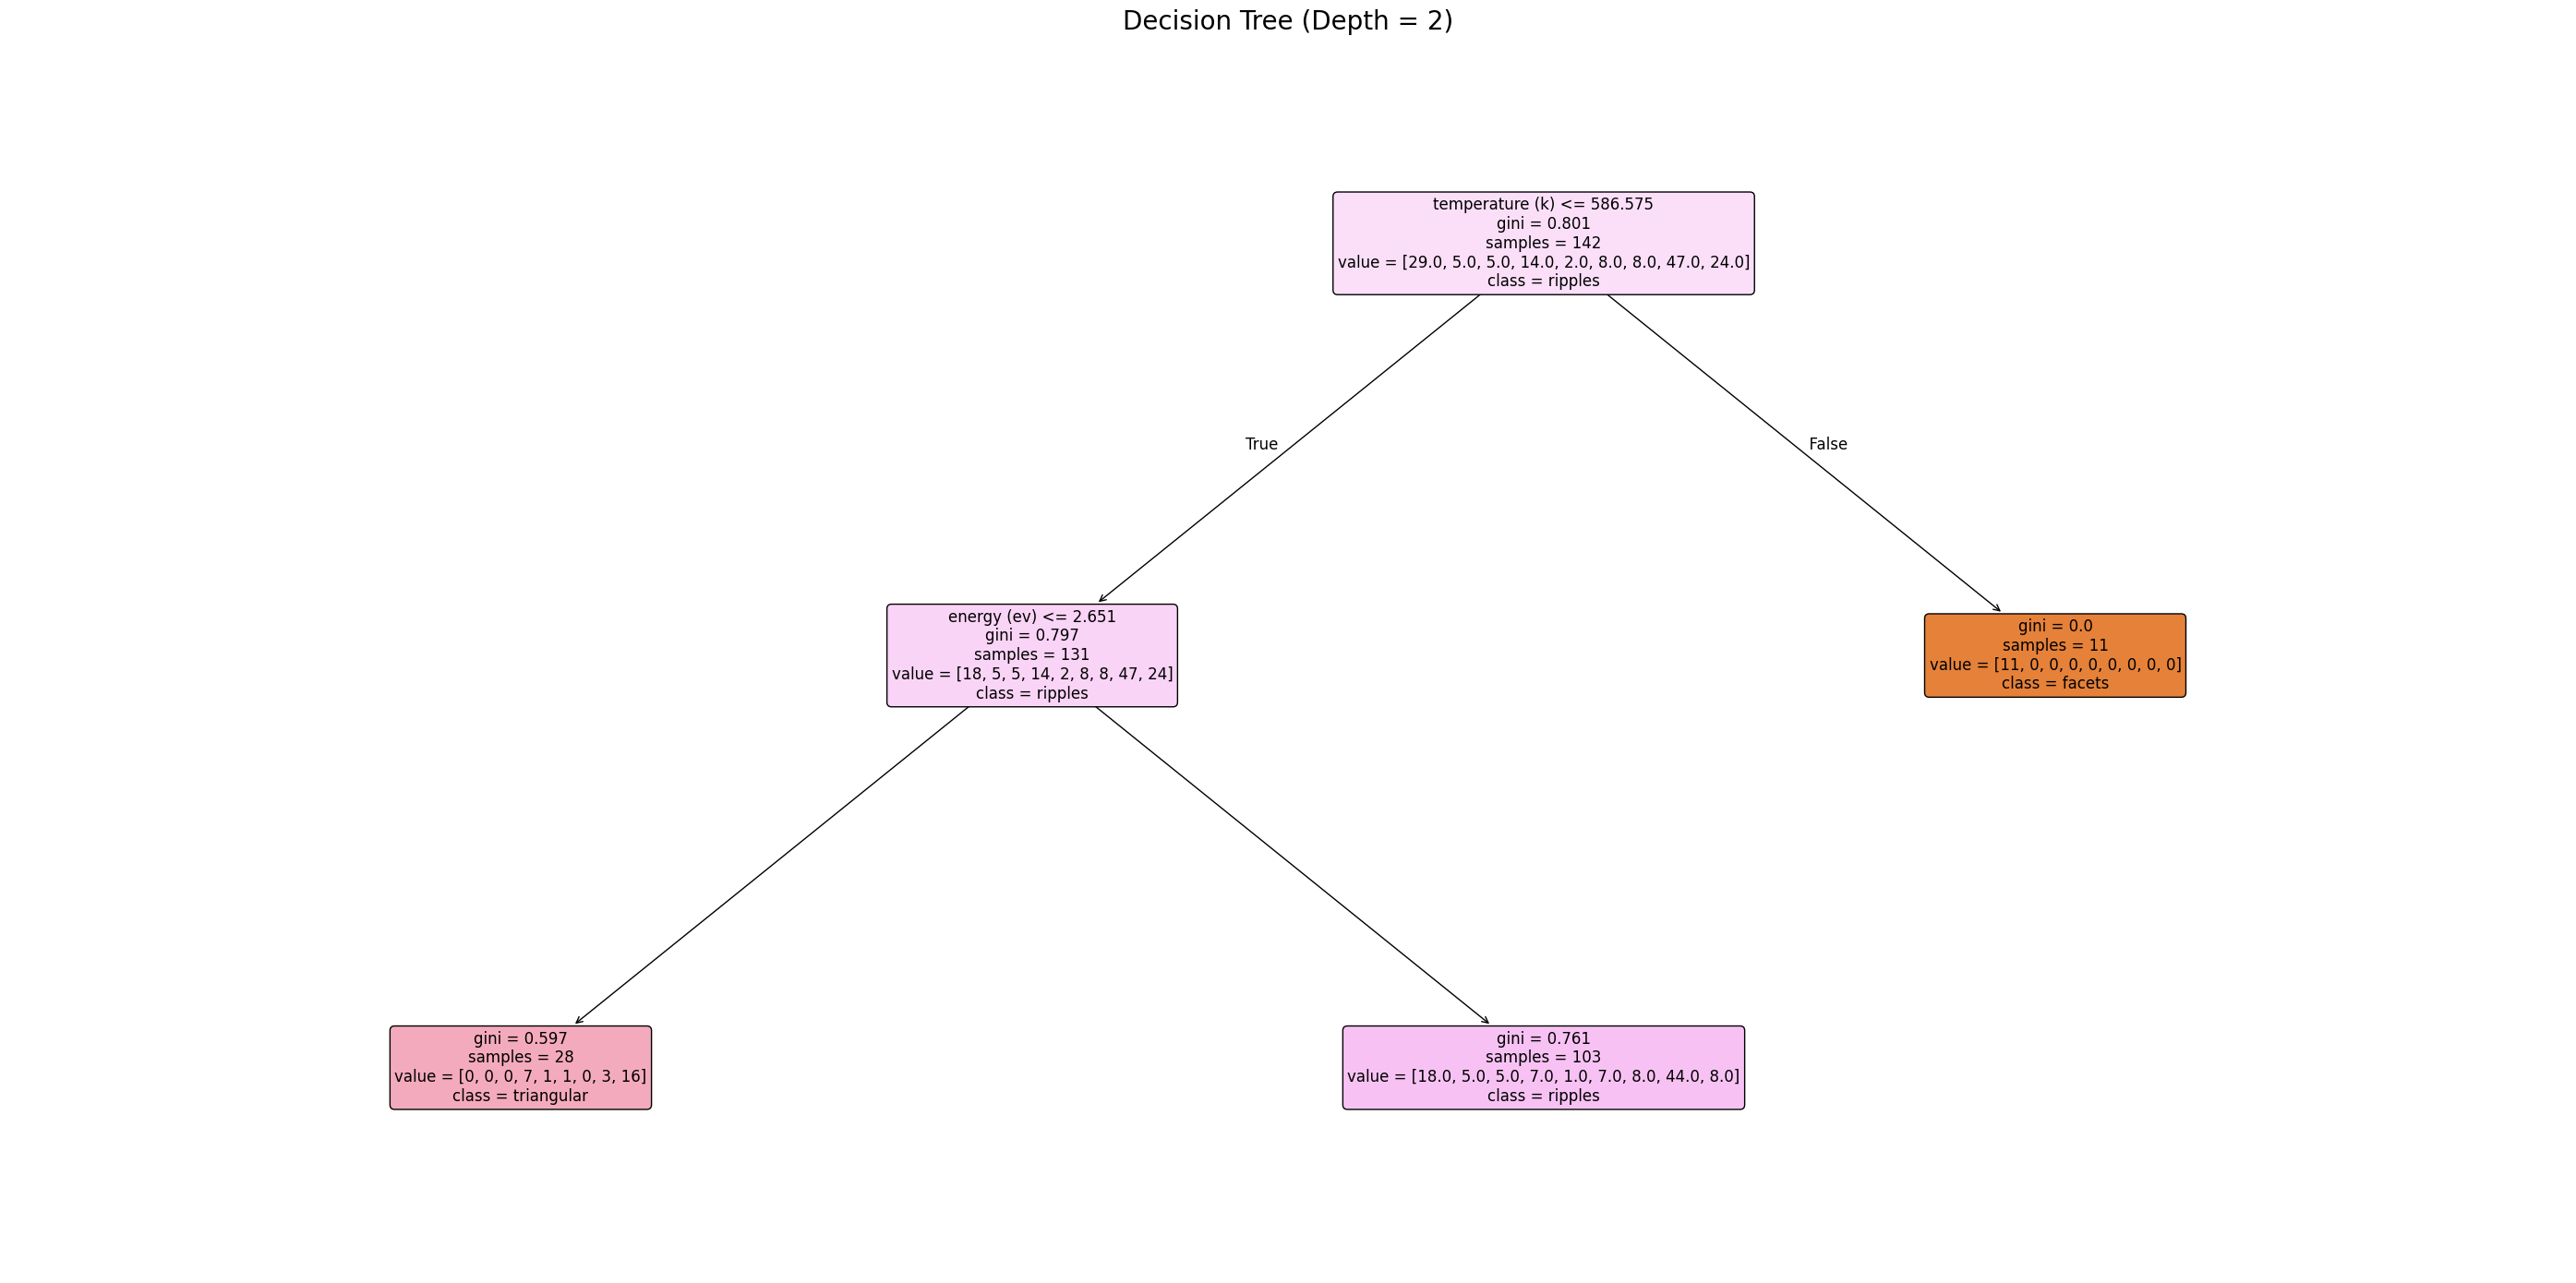

NameError: name 'export_text' is not defined